# CNN something

## Imports

In [ ]:
!pip install num2words

In [ ]:
!pip install pyctcdecode


In [ ]:
!pip install pyctcdecode
!pip install git+https://github.com/kpu/kenlm.git


In [ ]:
import multiprocessing

In [ ]:
from num2words import num2words

In [3]:
%%capture
import pandas as pd
import os
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import numpy as np
from pyctcdecode import build_ctcdecoder


## Data Loading

In [ ]:
ARCHIVE_PATH = "/kaggle/input/asr-data/train/train.tar.gz"
EXTRACT_DIR = "/kaggle/working/"

!tar -xzf "$ARCHIVE_PATH" -C "$EXTRACT_DIR"



In [ ]:
!ls /content/train | head


0007c21c23.wav
000bee1b1d.wav
001a718902.wav
001e8e5565.wav
001ee5be6b.wav
002006039c.wav
0023aeb702.wav
0025aa83a3.wav
002ac85f40.wav
002d609255.wav


In [ ]:
ARCHIVE_PATH_VAL = "/content/val.tar.gz"

EXTRACT_DIR_VAL = "/content/"

!tar -xzf "$ARCHIVE_PATH_VAL" -C "$EXTRACT_DIR_VAL"

In [ ]:
!ls /content/dev | head

0025d6d9a9.wav
0030479d60.mp3
003085d7a4.mp3
0047ca69ae.wav
00b89e507d.mp3
00d1de707e.wav
011d24e94d.mp3
015ad043f5.wav
01640a7be7.wav
0173eb22d0.wav


In [ ]:
CSV_PATH_TRAIN = "/kaggle/input/asr-data/train/train.csv"
AUDIO_ROOT_TRAIN = "/kaggle/input/asr-data/train/"


In [ ]:
VAL_CSV_PATH = "/kaggle/input/asr-data/val/dev.csv"
VAL_AUDIO_ROOT = "/kaggle/input/asr-data/val"

## Data Prep

In [ ]:
def normalize_number_to_text(number: int) -> str:
    text = num2words(number, lang="ru")
    return text.replace(",", "")



In [ ]:
def load_data(csv_path: str, audio_root: str):
    df = pd.read_csv(csv_path)
    samples = []
    for _, row in df.iterrows():
        full_path = os.path.join(audio_root, row["filename"])
        transcription_text = normalize_number_to_text(int(row["transcription"]))
        sample = {
            "wav_path": full_path,
            "text": transcription_text,
            "spk_id": row["spk_id"],
        }
        samples.append(sample)
    return samples


In [ ]:
samples_train = load_data(
    csv_path=CSV_PATH_TRAIN,
    audio_root=AUDIO_ROOT_TRAIN
)


In [ ]:
samples_val = load_data(
    csv_path=VAL_CSV_PATH,
    audio_root=VAL_AUDIO_ROOT
)

In [ ]:
print(samples_train[0])


{'wav_path': '/kaggle/input/asr-data/train/train/0007c21c23.wav', 'text': 'сто тридцать девять тысяч четыреста семьдесят три', 'spk_id': 'spk_E'}


In [ ]:
def build_vocab(samples):
    charset = set()
    for sample in samples:
        charset.update(sample["text"])
    charset = sorted(list(charset))
    char2idx = {c: i + 1 for i, c in enumerate(charset)}  # +1 чтобы 0 зарезервировать под PAD
    char2idx["<PAD>"] = 0
    idx2char = {i: c for c, i in char2idx.items()}
    return char2idx, idx2char


In [ ]:
char2idx, idx2char = build_vocab(samples_train)
print(char2idx)


{' ': 1, 'а': 2, 'в': 3, 'д': 4, 'е': 5, 'и': 6, 'к': 7, 'м': 8, 'н': 9, 'о': 10, 'п': 11, 'р': 12, 'с': 13, 'т': 14, 'ц': 15, 'ч': 16, 'ш': 17, 'ы': 18, 'ь': 19, 'я': 20, '<PAD>': 0}


In [ ]:
class SpeechDataset(torch.utils.data.Dataset):
    def __init__(self, samples, char2idx, target_sample_rate=16000, train=False):
        self.samples = samples
        self.char2idx = char2idx
        self.target_sr = target_sample_rate
        self.train = train


        self.melspec = T.MelSpectrogram(
            sample_rate=target_sample_rate,
            n_fft=400,
            win_length=400,
            hop_length=160,
            n_mels=80)


        self.augment = torch.nn.Sequential(
            # T.Vol(gain=(0.5, 1.5), gain_type="multiplicative"),
            T.Vol(gain=(0.8, 1.2), gain_type="multiplicative"),

            # T.AdditiveGaussianNoise(mean=0., std=0.005),
            T.FrequencyMasking(freq_mask_param=1),
            T.TimeMasking(time_mask_param=30)
    )


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]


        waveform, sr = torchaudio.load(sample["wav_path"])


        if sr != self.target_sr:
           resampler = T.Resample(orig_freq=sr, new_freq=self.target_sr)
           waveform = resampler(waveform)


        if self.train:
            waveform = self.augment(waveform)


        melspec = self.melspec(waveform).squeeze(0)
        log_melspec = torch.log(melspec + 1e-6)


        text = sample["text"]
        tokens = [self.char2idx[c] for c in text]

        return {
            "logmel": log_melspec,
            "tokens": torch.tensor(tokens, dtype=torch.long),
            "input_len": log_melspec.shape[-1],
            "target_len": len(tokens),
            "spk_id": sample["spk_id"]
        }

In [ ]:
train_dataset = SpeechDataset(samples_train, char2idx, train=True)

In [ ]:
example = train_dataset[0]

checking the augmentation out

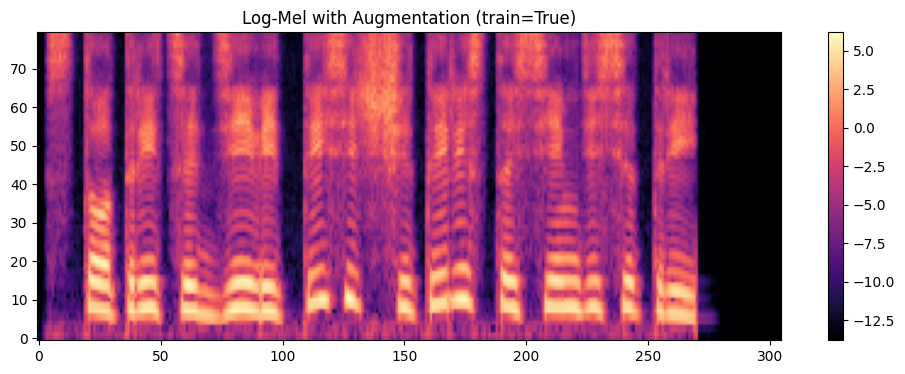

In [ ]:
sample = train_dataset[0]
logmel = sample["logmel"]

plt.figure(figsize=(12, 4))
plt.imshow(logmel.numpy(), origin="lower", aspect="auto", cmap="magma")
plt.title("Log-Mel with Augmentation (train=True)")
plt.colorbar()
plt.show()

📊 Waveform stats — Mean: -3.262441896367818e-05 Std: 0.09465896338224411
Min: -0.6040176153182983 Max: 0.3107507824897766


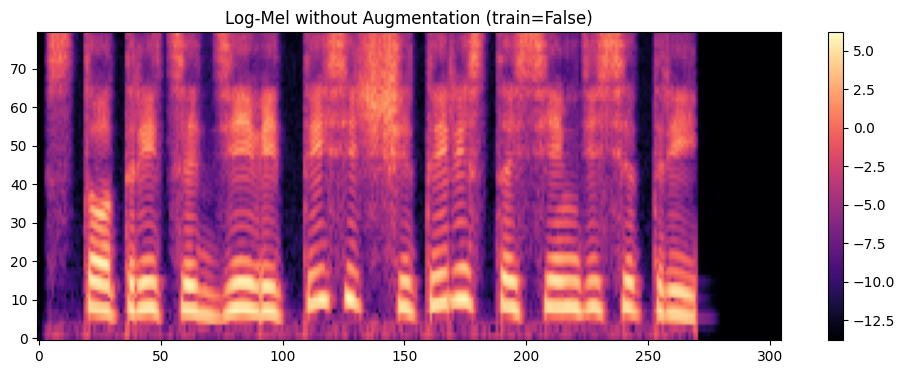

In [ ]:
dataset_clean = SpeechDataset(samples, char2idx, train=False)
logmel_clean = dataset_clean[0]["logmel"]

plt.figure(figsize=(12, 4))
plt.imshow(logmel_clean.numpy(), origin="lower", aspect="auto", cmap="magma")
plt.title("Log-Mel without Augmentation (train=False)")
plt.colorbar()
plt.show()

In [ ]:
print(example["logmel"].shape)

torch.Size([80, 305])


In [ ]:
print(example["tokens"])

tensor([13, 14, 10,  1, 14, 12,  6,  4, 15,  2, 14, 19,  1,  4,  5,  3, 20, 14,
        19,  1, 14, 18, 13, 20, 16,  1, 16,  5, 14, 18, 12,  5, 13, 14,  2,  1,
        13,  5,  8, 19,  4,  5, 13, 20, 14,  1, 14, 12,  6])


In [ ]:
print(example["spk_id"])

spk_E


In [ ]:
def collate_fn(batch):

    logmels = [item["logmel"].transpose(0, 1) for item in batch]
    tokens = [item["tokens"] for item in batch]


    logmel_lengths = torch.tensor([m.shape[1] for m in logmels], dtype=torch.long)
    token_lengths = torch.tensor([len(t) for t in tokens], dtype=torch.long)


    logmel_padded = pad_sequence(logmels, batch_first=True).transpose(1, 2)
    tokens_padded = pad_sequence(tokens, batch_first=True, padding_value=0)

    return {
        "logmel": logmel_padded,
        "logmel_len": logmel_lengths,
        "tokens": tokens_padded,
        "token_len": token_lengths
    }

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

In [ ]:
val_dataset = SpeechDataset(samples_val, char2idx, train=False)

In [ ]:
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [ ]:
batch = next(iter(train_loader))


In [ ]:
print("Logmel shape:", batch["logmel"].shape)
print("Tokens shape:", batch["tokens"].shape)
print("Logmel lens:", batch["logmel_len"])
print("Token lens:", batch["token_len"])


Logmel shape: torch.Size([32, 80, 352])
Tokens shape: torch.Size([32, 58])
Logmel lens: tensor([80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80,
        80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80])
Token lens: tensor([50, 43, 41, 49, 38, 53, 51, 46, 42, 52, 41, 37, 49, 34, 49, 41, 38, 42,
        45, 43, 49, 41, 58, 33, 35, 37, 46, 52, 54, 54, 32, 40])


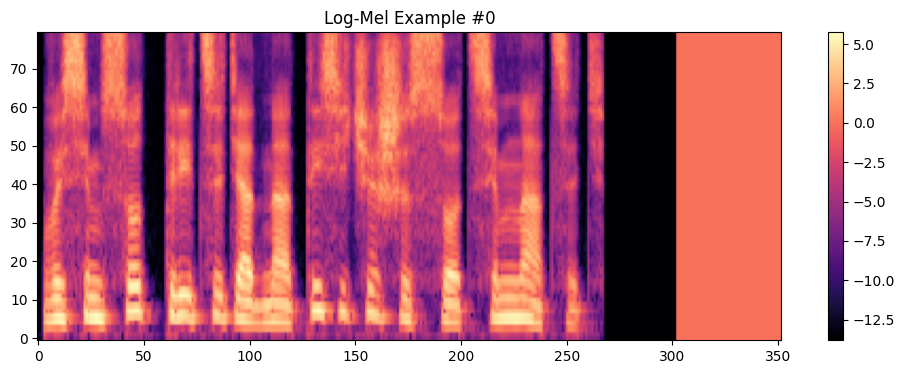

In [ ]:
i = 0
logmel = batch["logmel"][i].numpy()

plt.figure(figsize=(12, 4))
plt.imshow(logmel, origin="lower", aspect="auto", cmap="magma")
plt.title(f"Log-Mel Example #{i}")
plt.colorbar()
plt.show()

## Building CNN

In [ ]:
class CNNEncoder(nn.Module):
    def __init__(self, in_channels=80, hidden_dim=512, num_classes=21):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Conv1d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Conv1d(512, 768, kernel_size=3, padding=1),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Conv1d(768, 768, kernel_size=3, padding=1),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Conv1d(768, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, input_lengths):
        x = self.conv(x)
        x = x.transpose(1, 2)
        logits = self.classifier(x)
        return F.log_softmax(logits, dim=-1)


In [ ]:
model = CNNEncoder(in_channels=80, hidden_dim=512, num_classes=len(char2idx))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total trainable parameters: {count_parameters(model):,}")


Total trainable parameters: 5,058,069


In [ ]:
criterion = nn.CTCLoss(blank=0, zero_infinity=True)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
model.train()

batch = next(iter(train_loader))
logmel = batch["logmel"]
logmel_len = batch["logmel_len"]
tokens = batch["tokens"]
token_len = batch["token_len"]

log_probs = model(logmel, logmel_len)
log_probs = log_probs.transpose(0, 1)

loss = criterion(log_probs, tokens, logmel_len, token_len)

print("Loss:", loss.item())


Loss: 3.7942488193511963


In [ ]:
def train_loop(model, train_loader, val_loader, criterion, optimizer, epochs=10, device='cuda'):
    model.to(device)

    for epoch in range(1, epochs + 1):
        print(f"\n Epoch {epoch}")
        model.train()
        train_loss = 0

        for batch in train_loader:
            logmel = batch["logmel"].to(device)
            logmel_len = batch["logmel_len"].to(device)
            tokens = batch["tokens"].to(device)
            token_len = batch["token_len"].to(device)

            optimizer.zero_grad()
            log_probs = model(logmel, logmel_len)
            log_probs = log_probs.transpose(0, 1)  # [time, batch, num_classes]
            loss = criterion(log_probs, tokens, logmel_len, token_len)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        print(f"Train Loss: {avg_train_loss:.4f}")

        # Валидация
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                logmel = batch["logmel"].to(device)
                logmel_len = batch["logmel_len"].to(device)
                tokens = batch["tokens"].to(device)
                token_len = batch["token_len"].to(device)

                log_probs = model(logmel, logmel_len)
                log_probs = log_probs.transpose(0, 1)
                loss = criterion(log_probs, tokens, logmel_len, token_len)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        print(f"Val Loss: {avg_val_loss:.4f}")


In [ ]:
def train_loop(model, train_loader, val_loader, criterion, optimizer, epochs=10, device=None):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model.to(device)

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}")
        model.train()
        train_loss = 0

        train_iter = tqdm(train_loader, desc="Train", leave=False)
        for batch in train_iter:
            logmel = batch["logmel"].to(device)
            logmel_len = batch["logmel_len"].to(device)
            tokens = batch["tokens"].to(device)
            token_len = batch["token_len"].to(device)

            optimizer.zero_grad()
            log_probs = model(logmel, logmel_len)
            log_probs = log_probs.transpose(0, 1)  # [T, B, C]
            loss = criterion(log_probs, tokens, logmel_len, token_len)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_iter.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader)
        print(f" Avg Train Loss: {avg_train_loss:.4f}")

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            val_iter = tqdm(val_loader, desc="Val", leave=False)
            for batch in val_iter:
                logmel = batch["logmel"].to(device)
                logmel_len = batch["logmel_len"].to(device)
                tokens = batch["tokens"].to(device)
                token_len = batch["token_len"].to(device)

                log_probs = model(logmel, logmel_len)
                log_probs = log_probs.transpose(0, 1)
                loss = criterion(log_probs, tokens, logmel_len, token_len)

                val_loss += loss.item()
                val_iter.set_postfix(loss=loss.item())

        avg_val_loss = val_loss / len(val_loader)
        print(f"Avg Val Loss: {avg_val_loss:.4f}")

        if device == 'cuda':
            torch.cuda.empty_cache()


In [ ]:
train_loop(model, train_loader, val_loader, criterion, optimizer, epochs=15)


🟢 Epoch 1


 Avg Train Loss: 2.1051


Avg Val Loss: 2.3672

🟢 Epoch 2


 Avg Train Loss: 1.8010


Avg Val Loss: 2.3337

🟢 Epoch 3


...

Avg Val Loss: 2.5125

🟢 Epoch 14


 Avg Train Loss: 1.3533


Avg Val Loss: 2.5743

🟢 Epoch 15


 Avg Train Loss: 1.3303


Avg Val Loss: 2.5870


looks awful. let's double prove it

## Inference + Decoding

In [ ]:
device = next(model.parameters()).device
logmel = logmel.to(device)
logmel_len = logmel_len.to(device)


In [ ]:
from collections import defaultdict
import torch

def ctc_beam_search(log_probs, beam_width=10, blank=0):

    T, C = log_probs.shape
    log_probs = log_probs.cpu().numpy()

    BeamEntry = lambda: {"path": [], "score": float('-inf')}
    beams = [{"path": [], "score": 0.0}]

    for t in range(T):
        new_beams = defaultdict(BeamEntry)
        for beam in beams:
            prev_path = beam["path"]
            prev_score = beam["score"]

            for c in range(C):
                new_path = prev_path.copy()
                if c != blank:
                    if not (len(new_path) > 0 and new_path[-1] == c):
                        new_path.append(c)
                new_path_key = tuple(new_path)
                score = prev_score + log_probs[t][c]

                if new_beams[new_path_key]["score"] < score:
                    new_beams[new_path_key]["path"] = new_path
                    new_beams[new_path_key]["score"] = score

        beams = sorted(new_beams.values(), key=lambda x: x["score"], reverse=True)[:beam_width]

    return beams[0]["path"]


In [ ]:
def decode_batch_beam_search(log_probs_batch, input_lengths, idx2char, beam_width=10):

    results = []
    B = log_probs_batch.shape[0]
    for b in range(B):
        lp = log_probs_batch[b][:input_lengths[b]]  # [T, C]
        pred = ctc_beam_search(lp, beam_width=beam_width)
        text = "".join([idx2char[i] for i in pred])
        results.append(text)
    return results


In [ ]:
batch = next(iter(val_loader))
logmel = batch["logmel"]
logmel_len = batch["logmel_len"]

device = next(model.parameters()).device
logmel = logmel.to(device)
logmel_len = logmel_len.to(device)

with torch.no_grad():
    log_probs = model(logmel, logmel_len)
    log_probs = log_probs.transpose(0, 1).transpose(0, 1)  # [B, T, C]

decoded_texts = decode_batch_beam_search(log_probs, logmel_len, idx2char, beam_width=5)
for text in decoded_texts[:5]:
    print(text)


осетсдсят ьст сть
дстьст 
т
тет тесяьсятсь
дест ьестс


## LM?

In [ ]:
with open("corpus.txt", "w", encoding="utf-8") as f:
    for sample in samples_train:
        f.write(sample["text"].lower().strip() + "\n")


In [ ]:
arpa_path = "/kaggle/input/nvidia-model/pytorch/default/1/ru-RU_default_2.0_pruned.arpa"


In [ ]:
bin_path = "/kaggle/input/ru-model-bin/pytorch/default/1/ru-RU_default_2.0_pruned.bin"

In [ ]:
labels = [idx2char[i] for i in range(len(idx2char))]

decoder = build_ctcdecoder(
    labels=labels,
    kenlm_model_path=bin_path,
    alpha=0.6,
    beta=0.8
)


In [ ]:
batch = next(iter(val_loader))
logmel = batch["logmel"].to(device)
logmel_len = batch["logmel_len"]

with torch.no_grad():
    log_probs = model(logmel, logmel_len.to(device))  # [B, T, C]
    log_probs = log_probs.cpu().numpy().transpose(1, 0, 2)  # -> [B, T, C]

logmel_len_np = logmel_len.cpu().numpy()
logits_list = [log_probs[i][:int(logmel_len_np[i])] for i in range(len(logmel_len_np))]

with multiprocessing.get_context("fork").Pool() as pool:
    decoded_texts = decoder.decode_batch(logits_list=logits_list, pool=pool)

for text in decoded_texts[:5]:
    print(text)



дпдптсдпдтпдптштп
деяяесеярядярер
сеттсееиятисс
естсмстсттстс
ттьтыттььтьт


In [ ]:
labels = [idx2char[i] for i in range(len(idx2char))]


In [ ]:
idx2char[0]

'<PAD>'

In [ ]:
decoded = np.argmax(log_probs, axis=-1)  # [B, T]
for sequence in decoded[:5]:
    text = ''.join([idx2char[idx] for idx in sequence])
    print(text)


<PAD>д<PAD>тдпдп<PAD>тттттстдптдттпддпт<PAD>штп<PAD>
од<PAD><PAD>еядяо<PAD><PAD><PAD><PAD><PAD>с<PAD><PAD><PAD><PAD>еяря<PAD>дяр<PAD>е<PAD>р<PAD>
с<PAD><PAD><PAD>ет<PAD>т<PAD><PAD><PAD><PAD><PAD><PAD>е<PAD><PAD><PAD><PAD>е<PAD>ия<PAD><PAD>ти<PAD>с<PAD>с<PAD>
е<PAD><PAD><PAD>сс<PAD>тт<PAD><PAD><PAD><PAD><PAD>м<PAD><PAD><PAD><PAD>т<PAD>ст<PAD><PAD>тс<PAD>т<PAD>с<PAD>
т<PAD><PAD>ттт<PAD>ь<PAD>тттттыт<PAD>тть<PAD>ть<PAD><PAD>ьт<PAD>ьтт<PAD>


officially - it looks awful